# 06 · Barrido de checkpoints del adapter — selección por calidad de generación

**Motivación:** la pérdida de entrenamiento del `TokenAdapter` (MSE de difusión sobre un único timestep aleatorio por muestra) es un indicador ruidoso e imperfecto de si un checkpoint genera bien tras el muestreo completo (50 pasos + CFG). Ya hemos visto casos concretos donde una época *más entrenada* (misma pérdida, incluso más baja) generaba **peor** que una época muy temprana. Ver `docs/03_lowlevel_multitarea_y_generacion.md`.

**Qué hace este notebook:** genera con VARIOS checkpoints del adapter (best / last / snapshots periódicos `epoch_XXXX.pt`) sobre el MISMO pequeño conjunto de muestras, y puntúa cada uno con la misma métrica que usa el Experimento 5 (similitud CLIP generada↔real, para correcto/permutado/cero) — así se elige el checkpoint por lo que realmente importa, no por la pérdida de entrenamiento.

**Pregunta que responde:** de todos los checkpoints guardados durante el entrenamiento del adapter, ¿cuál genera imágenes más fieles a la fMRI correcta (y con mayor margen sobre permutado/cero)?

In [1]:
# Run from the PROJECT ROOT so relative paths (configs/, data/, outputs/)
# resolve exactly like the scripts do.
import sys, os
_root = os.getcwd()
while _root != os.path.dirname(_root):
    if os.path.isdir(os.path.join(_root, 'src')) and os.path.isdir(os.path.join(_root, 'configs')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root)
sys.path.insert(0, _root)
print('project root:', os.getcwd())
import matplotlib.pyplot as plt
from PIL import Image
from src.utils import load_config
from src.generation import discover_adapter_checkpoints, sweep_adapter_checkpoints
from src.utils import get_experiment_paths

cfg = load_config('configs/exp04_generation_v4_f2.yaml')
# Fuerza un modo que SÍ cargue el adapter (adapter | adapter_lowlevel);
# con lowlevel_img2img todos los checkpoints darían la MISMA imagen.
# cfg['generation']['mode'] = 'adapter_lowlevel'
paths = get_experiment_paths(cfg, ensure=False)
checkpoints = discover_adapter_checkpoints(paths.checkpoints)
print(f'{len(checkpoints)} checkpoints encontrados en {paths.checkpoints}:')
for label, p in checkpoints:
    print(' -', label, '->', p.name)

project root: c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion
7 checkpoints encontrados en outputs\exp04_generation_v4_f2\checkpoints:
 - best -> adapter_best.pt
 - last -> adapter_last.pt
 - epoch_0001 -> epoch_0001.pt
 - epoch_0005 -> epoch_0005.pt
 - epoch_0010 -> epoch_0010.pt
 - epoch_0015 -> epoch_0015.pt
 - epoch_0020 -> epoch_0020.pt


In [2]:
cfg['generation']['mode']

'adapter'

## Lanzar el barrido
`num_samples` pequeño (4–8) y `num_inference_steps` reducido para una pasada rápida de diagnóstico; sube ambos para los números finales que vayan a la memoria.

In [3]:
decoder_checkpoint = cfg.get('generation.decoder_checkpoint') \
    or 'outputs/exp03_lowlevel_multitask/checkpoints/best.pt'

result = sweep_adapter_checkpoints(
    cfg, decoder_checkpoint, checkpoints=checkpoints,
    conditions=['correct', 'permuted', 'zero'],
    num_samples=50, num_inference_steps=50)
print('Resultados guardados en:', result['out_dir'])

10:24:07 | INFO    | datamodule | Loading cached split metadata: data\processed\metadata_subj01.csv
10:24:07 | INFO    | datamodule | Prepared 1 subject(s) ['subj01'] | test_split=official | samples: {'train': np.int64(8857), 'val': np.int64(984), 'test': np.int64(159)} | voxels: {'subj01': 39548}


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


10:24:18 | INFO    | clip | Loaded open_clip ViT-L-14/openai (dim=768)


Loading pipeline components...: 100%|██████████| 4/4 [00:02<00:00,  1.64it/s]


10:24:22 | INFO    | checkpoint_sweep | Sweeping checkpoint 'best': outputs\exp04_generation_v4_f2\checkpoints\adapter_best.pt


c:\Users\xxdia\Documents\TFM\tfm_fmri_diffusion\.tfm_fmri_diffusion_3_11\Lib\site-packages\diffusers\pipelines\pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


10:24:23 | INFO    | sd | Loaded token adapter from outputs\exp04_generation_v4_f2\checkpoints\adapter_best.pt
10:39:57 | INFO    | checkpoint_sweep | Sweeping checkpoint 'last': outputs\exp04_generation_v4_f2\checkpoints\adapter_last.pt
10:39:58 | INFO    | sd | Loaded token adapter from outputs\exp04_generation_v4_f2\checkpoints\adapter_last.pt
10:55:46 | INFO    | checkpoint_sweep | Sweeping checkpoint 'epoch_0001': outputs\exp04_generation_v4_f2\checkpoints\epoch_0001.pt
10:55:46 | INFO    | sd | Loaded token adapter from outputs\exp04_generation_v4_f2\checkpoints\epoch_0001.pt
11:11:35 | INFO    | checkpoint_sweep | Sweeping checkpoint 'epoch_0005': outputs\exp04_generation_v4_f2\checkpoints\epoch_0005.pt
11:11:35 | INFO    | sd | Loaded token adapter from outputs\exp04_generation_v4_f2\checkpoints\epoch_0005.pt
11:27:11 | INFO    | checkpoint_sweep | Sweeping checkpoint 'epoch_0010': outputs\exp04_generation_v4_f2\checkpoints\epoch_0010.pt
11:27:12 | INFO    | sd | Loaded token a

## Tabla resumen (una fila por checkpoint × condición)

In [4]:
summary = result['summary']
summary.pivot_table(index=['checkpoint', 'epoch'], columns='condition',
                    values='mean_clip_similarity')

,condition,correct,permuted,zero
checkpoint,epoch,,,
best,18,0.587546,0.588764,0.589155
epoch_0001,0,0.629058,0.591117,0.578608
epoch_0005,4,0.597196,0.592769,0.572353
epoch_0010,9,0.591930,0.584563,0.578746
epoch_0015,14,0.590475,0.589385,0.587413
epoch_0020,19,0.587510,0.589418,0.589493
last,19,0.587510,0.589418,0.589493


## Margen correcto − mejor control, por checkpoint
`uses_fmri_signal=True` cuando la fMRI correcta supera claramente a permutado/cero con ESE checkpoint concreto — es el mismo criterio que `conclusion_from_summary` usa en el Experimento 2, aplicado aquí a la generación.

In [5]:
result['margins']

,checkpoint,epoch,correct,best_control,margin,uses_fmri_signal
2,epoch_0001,0,0.629058,0.591117,0.037940,True
3,epoch_0005,4,0.597196,0.592769,0.004427,True
4,epoch_0010,9,0.591930,0.584563,0.007367,True
5,epoch_0015,14,0.590475,0.589385,0.001090,True
0,best,18,0.587546,0.589155,-0.001610,False
1,last,19,0.587510,0.589493,-0.001983,False
6,epoch_0020,19,0.587510,0.589493,-0.001983,False


## Curva de calidad a lo largo del entrenamiento
Si la pérdida de entrenamiento fuera un buen proxy, esperaríamos una curva `correct` estable o creciente con la época. Si en cambio baja o es errática, confirma que hay que elegir el checkpoint por esta métrica y no por `best_loss`.

In [6]:
%matplotlib inline

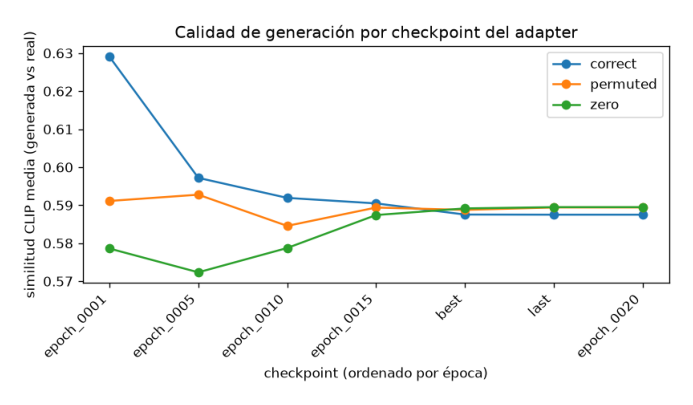

In [7]:
from PIL import Image as _Image
fig_path = f"{result['out_dir']}/checkpoint_sweep_quality.png"
plt.figure(figsize=(9, 5)); plt.imshow(_Image.open(fig_path)); plt.axis('off'); plt.show()

## Inspección visual — rejilla [real | correcto | permutado | cero] por checkpoint

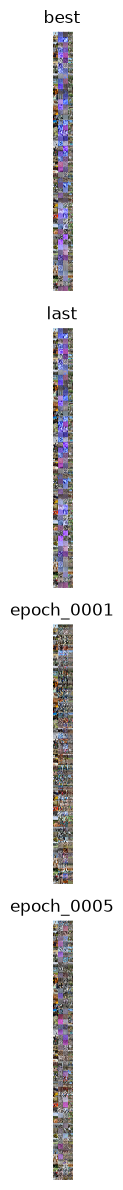

In [8]:
labels = list(result['images'].keys())
n = min(4, len(labels))
fig, axes = plt.subplots(n, 1, figsize=(10, 3*n))
axes = axes if n > 1 else [axes]
for ax, label in zip(axes, labels[:n]):
    grid_path = f"{result['out_dir']}/{label}/comparison_grid.png"
    ax.imshow(_Image.open(grid_path)); ax.axis('off'); ax.set_title(label)
plt.tight_layout(); plt.show()

## Elegir el checkpoint ganador
Criterio recomendado: mayor `margin` (correcto − mejor control) en la tabla anterior, desempatando por mayor `mean_clip_similarity` de `correct`. Ese es el checkpoint a usar en `generation.adapter_checkpoint` para las generaciones finales del Experimento 4/5 — no necesariamente `adapter_best.pt`.

In [9]:
best_row = result['margins'].sort_values('margin', ascending=False).iloc[0]
print('Checkpoint recomendado:', best_row['checkpoint'],
      '| epoch:', best_row['epoch'], '| margin:', round(best_row['margin'], 4))

Checkpoint recomendado: epoch_0001 | epoch: 0 | margin: 0.0379
